In [44]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

# Modeling
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules


In [45]:
pip install mlxtend
# cách cài đặt thư viện

SyntaxError: invalid syntax (1723465286.py, line 1)

In [ ]:
# Read data files
orders = pd.read_csv('./input/brazilian-ecommerce/olist_orders_dataset.csv')
payments = pd.read_csv('./input/brazilian-ecommerce/olist_order_payments_dataset.csv')
reviews = pd.read_csv('./input/brazilian-ecommerce/olist_order_reviews_dataset.csv')
customers = pd.read_csv('./input/brazilian-ecommerce/olist_customers_dataset.csv')

# **A. Data Understanding**

## **1. Data Overview**

What we will identify:
- Shape of each data frame (number of rows and columns)
- How many missing values in each column (null values)?
- How many unique values in each feature (column)?

#### **1.1. orders**

In [ ]:
# Print out first 5 rows of the data frame `orders`
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [ ]:
# Print out the names of all columns in `orders`
orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='str')

In [ ]:
# Print out data type of each column
orders.dtypes

order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

##### a) Shape

In [ ]:
# Shape of the data frame `orders`
print(orders.shape)

(99441, 8)


The data frame `orders` has 99441 rows and 8 columns.

In [ ]:
# To print only the number of rows
print(orders.shape[0])

99441


In [ ]:
# To print only the number of columns
print(orders.shape[1])

8


##### b) Missing values

In [ ]:
# Print out the total missing values of each feature (column)
print(orders.isna().sum())

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


- `order_approved_at` column has 160 null values, accounting for 0.16%.
- `order_delivered_carrier_date` column has 1783 null values, accounting for 1.79%.
- `order_delivered_customer_date` column has 2965 null values, accounting for 2.98%.
- Others columns has no missing values.

##### c) Unique values

In [ ]:
print(orders.nunique())

order_id                         99441
customer_id                      99441
order_status                         8
order_purchase_timestamp         98875
order_approved_at                90733
order_delivered_carrier_date     81018
order_delivered_customer_date    95664
order_estimated_delivery_date      459
dtype: int64


#### **1.2. Payments**

In [ ]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [ ]:
payments.columns

Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='str')

In [ ]:
payments.dtypes

order_id                    str
payment_sequential        int64
payment_type                str
payment_installments      int64
payment_value           float64
dtype: object

##### a) Shape

In [ ]:
payments.shape

(103886, 5)

##### b) Mising values

In [ ]:
payments.isna().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

##### c) Unique values

In [ ]:
payments.nunique()

order_id                99440
payment_sequential         29
payment_type                5
payment_installments       24
payment_value           29077
dtype: int64

#### **1.3. Reviews**

In [ ]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [ ]:
reviews.columns

Index(['review_id', 'order_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp'],
      dtype='str')

In [ ]:
reviews.dtypes

review_id                    str
order_id                     str
review_score               int64
review_comment_title         str
review_comment_message       str
review_creation_date         str
review_answer_timestamp      str
dtype: object

##### a) Shape

In [ ]:
reviews.shape

(99224, 7)

##### b) Missing values

In [ ]:
reviews.isna().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

##### c) Unique values

In [ ]:
reviews.nunique()

review_id                  98410
order_id                   98673
review_score                   5
review_comment_title        4527
review_comment_message     36159
review_creation_date         636
review_answer_timestamp    98248
dtype: int64

#### **1.4. customers**

In [ ]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [ ]:
customers.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='str')

In [ ]:
customers.dtypes

customer_id                   str
customer_unique_id            str
customer_zip_code_prefix    int64
customer_city                 str
customer_state                str
dtype: object

##### a) Shape

In [ ]:
customers.shape

(99441, 5)

##### b) Missing values

In [ ]:
customers.isna().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

##### c) Unique values

In [ ]:
customers.nunique()

customer_id                 99441
customer_unique_id          96096
customer_zip_code_prefix    14994
customer_city                4119
customer_state                 27
dtype: int64

#### **1.5. Summary**

In [ ]:
# Collections for each dataset
datasets = [orders, payments, reviews, customers]
names = ['orders', 'payments', 'reviews', 'customers']

# Creating a DataFrame with useful information about all datasets
data_info = pd.DataFrame({})
data_info['dataset'] = names
data_info['n_rows'] = [df.shape[0] for df in datasets]
data_info['n_cols'] = [df.shape[1] for df in datasets]
data_info['null_amount'] = [df.isnull().sum().sum() for df in datasets]
data_info['null_columns_num'] = [len([col for col, null in df.isnull().sum().items() if null > 0]) for df in datasets]
data_info['null_columns'] = [', '.join([col for col, null in df.isnull().sum().items() if null > 0]) for df in datasets]

data_info.style.background_gradient()

,dataset,n_rows,n_cols,null_amount,null_columns_num,null_columns
0,orders,99441,8,4908,3,"order_approved_at, order_delivered_carrier_date, order_delivered_customer_date"
1,payments,103886,5,0,0,
2,reviews,99224,7,145903,2,"review_comment_title, review_comment_message"
3,customers,99441,5,0,0,


In [47]:
overview_frames = []

for name, df in zip(names, datasets):
    num_cat = [df[col].nunique() if df[col].dtype == 'object' else 0 for col in df.columns]
    
    temp_df = pd.DataFrame({
        'dataset_name': name,
        'feature': df.columns,
        'null_num': df.isnull().sum().values,
        'null_percentage': df.isnull().sum().values / len(df),
        'dtype': df.dtypes.astype(str).values,
        'category_num': num_cat
    })
    
    overview_frames.append(temp_df)

df_overview = pd.concat(overview_frames)
df_overview

,dataset_name,feature,null_num,null_percentage,dtype,category_num
0,orders,order_id,0,0.000000,str,0
1,orders,customer_id,0,0.000000,str,0
2,orders,order_status,0,0.000000,str,0
3,orders,order_purchase_timestamp,0,0.000000,str,0
4,orders,order_approved_at,160,0.001609,str,0
5,orders,order_delivered_carrier_date,1783,0.017930,str,0
6,orders,order_delivered_customer_date,2965,0.029817,str,0
7,orders,order_estimated_delivery_date,0,0.000000,str,0
0,payments,order_id,0,0.000000,str,0
1,payments,payment_sequential,0,0.000000,int64,0


**Observation:**


In [48]:
payments.columns

Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='str')

In [49]:
# 1. Group payments by order_id
# Group all payment_types of the same order_id into a single list.
grouped_payments = payments.groupby('order_id').agg({
    'payment_type': lambda x: list(x)
    }).reset_index()

# 2. Filter to see which orders have payment lists containing more than 1 element.
split_payment_orders = grouped_payments[grouped_payments['payment_type'].apply(len) > 1]

split_payment_orders.head(10)

,order_id,payment_type
36,0016dfedd97fc2950e388d2971d718c7,"[voucher, credit_card]"
73,002f19a65a2ddd70a090297872e6d64e,"[voucher, voucher]"
161,0071ee2429bc1efdc43aa3e073a5290e,"[voucher, voucher]"
215,009ac365164f8e06f59d18a08045f6c4,"[voucher, voucher, credit_card, voucher, vouch..."
258,00b4a910f64f24dbcac04fe54088a443,"[voucher, credit_card]"
274,00bd50cdd31bd22e9081e6e2d5b3577b,"[voucher, voucher, credit_card]"
282,00c405bd71187154a7846862f585a9d4,"[voucher, voucher, voucher, voucher, voucher, ..."
295,00c95282163553a982f38481f9488481,"[credit_card, voucher, voucher, voucher]"
338,00e6bc6b166eb28b4502c1cad4457248,"[credit_card, voucher]"
464,013037c3f1773cc8fdbaf8ff54d8013b,"[credit_card, voucher]"


In [50]:
split_payment_orders.shape[0]

2961

## **2. Data Cleaning**

#### **2.1. orders**

Missing values in:
1. `order_approved_at`: Shows the payment approval timestamp.
2. `order_delivered_carrier_date`: Shows the order posting timestamp. When it was handled to the logistic partner.
3. `order_delivered_customer_date`: Shows the actual order delivery date to the customer.

In [51]:
orders.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Assumption: Null values may be in orders which are not delivered. In this problem, we will need to calculate how late or early an order is delivered. So, filtering data to keep delivered orders only.

In [52]:
orders['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [53]:
orders.shape[0]

99441

In [54]:
# Keep orders that are delivered only
orders_cleaned = orders[orders['order_status'] == 'delivered'].copy()
orders_cleaned['order_status'].value_counts()

order_status
delivered    96478
Name: count, dtype: int64

In [55]:
orders_cleaned.shape[0]

96478

In [56]:
orders_cleaned.isna().sum()

order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      2
order_delivered_customer_date     8
order_estimated_delivery_date     0
dtype: int64

In [57]:
# Drop all rows with any null values
orders_cleaned = orders_cleaned.dropna()
orders_cleaned.shape[0]

96455

In [58]:
orders_cleaned.isna().sum()

order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
dtype: int64

#### **2.2. reviews**

Missing values in:
1. `review_comment_title`: Comment title from the review left by the customer.
2. `review_comment_message`: Comment message from the review left by the customer.

Reason: When leaving a review, customers only select the number of stars (from 1 to 5), while writing a Title and a Message is optional. Therefore, there is a large number of blank spaces.

Since our FPM problem doesn't use Natural Language Processing (NLP) to read comments, we can completely remove (Drop column) the `review_comment_title` and `review_comment_message` columns from the Dataframe right now.

In [59]:
reviews.isna().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [60]:
reviews_cleaned = reviews.drop(columns=['review_comment_title', 'review_comment_message'])
reviews_cleaned.isna().sum()


review_id                  0
order_id                   0
review_score               0
review_creation_date       0
review_answer_timestamp    0
dtype: int64

#### **2.3. payments and customers**

No null values!

In [61]:
payments_cleaned = payments.copy()
customers_cleaned = customers.copy()

## **3. Data Visualization**

In [62]:
orders_cleaned.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='str')

In [63]:
orders_cleaned[['order_delivered_customer_date', 'order_estimated_delivery_date']].head(10)

,order_delivered_customer_date,order_estimated_delivery_date
0,2017-10-10 21:25:13,2017-10-18 00:00:00
1,2018-08-07 15:27:45,2018-08-13 00:00:00
2,2018-08-17 18:06:29,2018-09-04 00:00:00
3,2017-12-02 00:28:42,2017-12-15 00:00:00
4,2018-02-16 18:17:02,2018-02-26 00:00:00
5,2017-07-26 10:57:55,2017-08-01 00:00:00
7,2017-05-26 12:55:51,2017-06-07 00:00:00
8,2017-02-02 14:08:10,2017-03-06 00:00:00
9,2017-08-16 17:14:30,2017-08-23 00:00:00
10,2017-05-29 11:18:31,2017-06-07 00:00:00


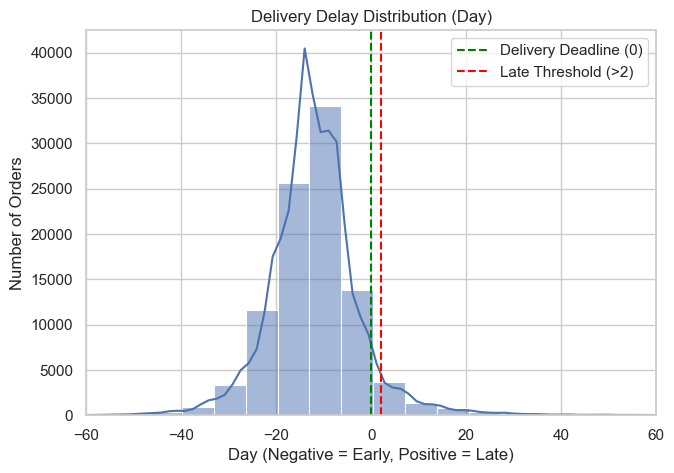

In [64]:
# Coerce the data types from String to Datetime.
orders_cleaned['order_delivered_customer_date'] = pd.to_datetime(orders_cleaned['order_delivered_customer_date'])
orders_cleaned['order_estimated_delivery_date'] = pd.to_datetime(orders_cleaned['order_estimated_delivery_date'])

# Calculate Delivery Delay
orders_cleaned['delivery_delay_days'] = (orders_cleaned['order_delivered_customer_date'] - orders_cleaned['order_estimated_delivery_date']).dt.days

# Setup style and size
sns.set_theme(style="whitegrid")
plt.figure(figsize=(25, 5))

plt.subplot(1, 3, 1)
sns.histplot(data=orders_cleaned, x='delivery_delay_days', bins=50, kde=True)
plt.axvline(x=0, color='green', linestyle='--', label='Delivery Deadline (0)')
plt.axvline(x=2, color='red', linestyle='--', label='Late Threshold (>2)')
plt.xlim(-60, 60)
plt.title('Delivery Delay Distribution (Day)')
plt.xlabel('Day (Negative = Early, Positive = Late)')
plt.ylabel('Number of Orders')
plt.legend()
plt.show()

Biểu đồ này đo lường hiệu quả vận chuyển (Số ngày thực tế so với dự kiến):

Giao hàng sớm: Phần lớn biểu đồ (vùng màu xanh) nằm ở phía bên trái đường kẻ xanh lá (mốc 0). Giá trị âm biểu thị hàng được giao sớm hơn dự kiến (trung bình sớm từ 10-20 ngày).

Đúng hạn: Đỉnh cao nhất tập trung quanh khoảng -15 đến -10 ngày, cho thấy hệ thống đang hứa hẹn thời gian giao hàng khá dư dả.

Giao hàng trễ: Các đơn hàng nằm bên phải đường kẻ đỏ (>2 ngày trễ) chiếm tỷ lệ rất thấp nhưng vẫn tồn tại, kéo dài đến mức trễ 20-40 ngày trong một số trường hợp cực đoan.

In [65]:
len(orders_cleaned[orders_cleaned['delivery_delay_days']>2])

5163

In [66]:
payments_cleaned.columns

Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='str')

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_19184\212165131.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=payments_cleaned, x='payment_installments', palette='viridis')
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_19184\212165131.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


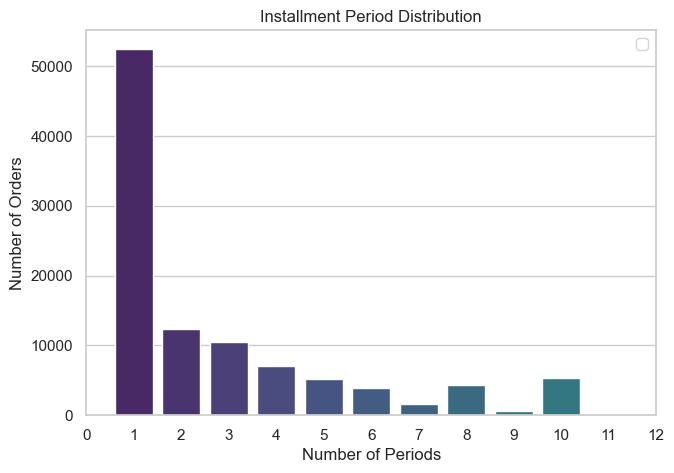

In [67]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(25, 5))

plt.subplot(1, 3, 2)
sns.countplot(data=payments_cleaned, x='payment_installments', palette='viridis')
plt.xlim(0, 12)
plt.title('Installment Period Distribution')
plt.xlabel('Number of Periods')
plt.ylabel('Number of Orders')
plt.legend()
plt.show()

Biểu đồ này thể hiện thói quen thanh toán của người mua:

Thanh toán một lần là chủ yếu: Cột cao nhất nằm ở 1 kỳ, với hơn 50,000 đơn hàng. Điều này cho thấy khách hàng ưu tiên trả thẳng.

Xu hướng giảm dần: Số lượng đơn hàng giảm mạnh khi số kỳ trả góp tăng lên.

Điểm đặc biệt: Có một sự tăng nhẹ ở mốc 8 kỳ và 10 kỳ so với các mốc lân cận (9 hoặc 11 kỳ), thường là do các chương trình ưu đãi trả góp phổ biến từ ngân hàng hoặc cửa hàng.

In [68]:
review_counts = reviews_cleaned['review_score'].value_counts().sort_index()

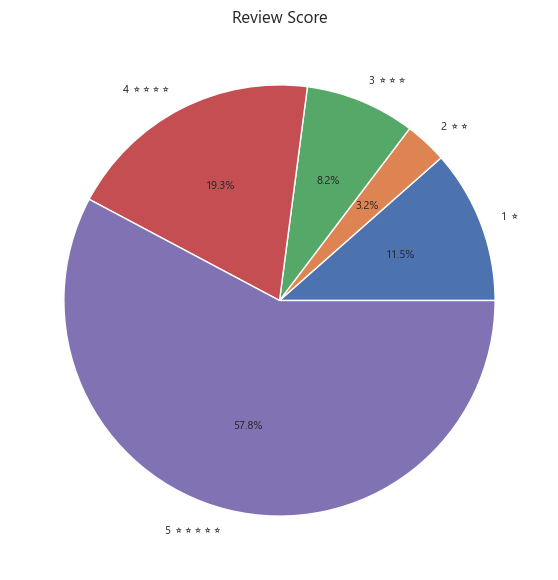

In [69]:
# Support special characters
mpl.rcParams['font.family'] = 'Segoe UI Symbol'

plt.figure(figsize=(7, 7)) 
plt.pie(review_counts, 
        labels=[f'{int(i)} ' + '⭐' * int(i) for i in review_counts.index], 
        autopct='%1.1f%%', 
        textprops={'fontsize': 8},
        colors=sns.color_palette("deep", 5))
plt.title('Review Score')
plt.show()

Biểu đồ này cho thấy mức độ hài lòng của khách hàng đối với sản phẩm hoặc dịch vụ:

Chiếm đa số tuyệt đối: Mức 5 sao chiếm tới 57.8%, cho thấy phần lớn khách hàng rất hài lòng.

Tích cực chung: Nếu cộng cả 4 sao (19.3%) và 5 sao, có khoảng 77.1% phản hồi tích cực.

Tiêu cực: Mức 1 sao khá đáng kể với 11.5%, đây là nhóm khách hàng gặp vấn đề nghiêm trọng cần được quan tâm.

# **B. Data Preprocessing**

In [70]:
orders_cleaned.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'delivery_delay_days'],
      dtype='str')

In [71]:
payments_cleaned.columns

Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='str')

In [72]:
customers_cleaned.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='str')

In [73]:
reviews_cleaned.columns

Index(['review_id', 'order_id', 'review_score', 'review_creation_date',
       'review_answer_timestamp'],
      dtype='str')

## **1. JOIN Data Frame**

Entity-Relationship Diagram Logic:
- `orders` $\leftrightarrow$ `customers` by `customer_id`
- `orders` $\leftrightarrow$ `payments` by `order_id`
- `orders` $\leftrightarrow$ `reviews` by `order_id`

Để JOIN 4 dataframe, sử dụng phương thức `pd.merge()` với tham số `how='inner'` để đảm bảo chỉ giữ lại những đơn hàng có đầy đủ thông tin (có khách hàng, có thanh toán và có đánh giá), tránh sinh ra các giá trị Null mới.

In [74]:
# 1. Merge Orders with Customers (Key: customer_id)
df = pd.merge(
    orders_cleaned, 
    customers_cleaned, 
    on='customer_id', 
    how='inner'
)
print(f"Number of rows and cols after JOIN Orders + Customers: {df.shape}")

# 2. Continue to merge with Payments (Key: order_id)
df = pd.merge(
    df, 
    payments_cleaned, 
    on='order_id', 
    how='inner'
)
print(f"Number of rows and cols after JOIN Payments: {df.shape}")

# 3. Continue to merge with Reviews (Key: order_id)
df = pd.merge(
    df, 
    reviews_cleaned, 
    on='order_id', 
    how='inner'
)
print(f"Number of rows and cols after JOIN Reviews (Complete): {df.shape}")

# 4. Xử lý trùng lặp do quan hệ 1-N 
# Một đơn hàng (order_id) có thể có nhiều lượt thanh toán (trả bằng 2 thẻ) 
# hoặc nhiều lượt đánh giá. Điều này làm số dòng phình to và sai lệch tần suất FPM.
# Giải pháp: Giữ lại dòng dữ liệu đầu tiên của mỗi order_id
df = df.drop_duplicates(subset=['order_id'], keep='first')

print(f"Number of rows and cols after removing duplicates: {df.shape}")

Number of rows and cols after JOIN Orders + Customers: (96455, 13)
Number of rows and cols after JOIN Payments: (100733, 17)
Number of rows and cols after JOIN Reviews (Complete): (100626, 21)
Number of rows and cols after removing duplicates: (95808, 21)


In [75]:
orders_cleaned.shape

(96455, 9)

In [76]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_delay_days,customer_unique_id,...,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,-8,7c396fd4830fd04220f754e42b4e5bff,...,sao paulo,SP,1,credit_card,1,18.12,a54f0611adc9ed256b57ede6b6eb5114,4,2017-10-11 00:00:00,2017-10-12 03:43:48
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,-6,af07308b275d755c9edb36a90c618231,...,barreiras,BA,1,boleto,1,141.46,8d5266042046a06655c8db133d120ba5,4,2018-08-08 00:00:00,2018-08-08 18:37:50
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,-18,3a653a41f6f9fc3d2a113cf8398680e8,...,vianopolis,GO,1,credit_card,3,179.12,e73b67b67587f7644d5bd1a52deb1b01,5,2018-08-18 00:00:00,2018-08-22 19:07:58
5,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,-13,7c142cf63193a1473d2e66489a9ae977,...,sao goncalo do amarante,RN,1,credit_card,1,72.20,359d03e676b3c069f62cadba8dd3f6e8,5,2017-12-03 00:00:00,2017-12-05 19:21:58
6,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,-10,72632f0f9dd73dfee390c9b22eb56dd6,...,santo andre,SP,1,credit_card,1,28.62,e50934924e227544ba8246aeb3770dd4,5,2018-02-17 00:00:00,2018-02-18 13:02:51


In [77]:
df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'delivery_delay_days', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value', 'review_id', 'review_score',
       'review_creation_date', 'review_answer_timestamp'],
      dtype='str')


Trong bài này, dữ liệu được lấy từ nhiều bảng khác nhau:
- `orders`
- `customers`
- `payments`
- `reviews`

Quá trình hợp nhất được thực hiện bằng hàm `pandas.merge()` với phương pháp **inner join**.

### Các bước thực hiện:
1. Gộp `orders` với `customers` theo `customer_id`
2. Gộp tiếp với `payments` theo `order_id`
3. Gộp tiếp với `reviews` theo `order_id`

### Mục đích:
- Chỉ giữ lại các bản ghi có đầy đủ thông tin
- Tránh dữ liệu bị thiếu (missing values)
- Đảm bảo chất lượng dữ liệu đầu vào cho mô hình


## **2. Feature Selection**

Chỉ giữ lại các biến cốt lõi cho bài toán: 
1. delivery_delay_days (Độ trễ)
2. payment_installments (Kỳ hạn trả góp)
3. payment_type (Phương thức thanh toán)
4. review_score (Điểm đánh giá - Biến mục tiêu)
5. customer_state (Bang của khách hàng - để xem có vùng nào hay bị trễ không).

In [82]:
cols_to_keep = ['delivery_delay_days', 'payment_installments', 'payment_type', 'review_score', 'customer_state']
df_filtered = df[cols_to_keep].copy()

In [79]:
df_filtered.shape

(95808, 5)

In [80]:
df_filtered.head()

,delivery_delay_days,payment_installments,payment_type,review_score,customer_state
0,-8,1,credit_card,4,SP
3,-6,1,boleto,4,BA
4,-18,3,credit_card,5,GO
5,-13,1,credit_card,5,RN
6,-10,1,credit_card,5,SP


Sau khi xử lý, các thuộc tính được chọn bao gồm:

- `delivery_status` (late / ontime)
- `installment_group` (1 / short / long)
- `payment_method`
- `review_category`
- `customer_location`

### Lý do:
- Đây là các thuộc tính dạng **categorical**
- Phù hợp với bài toán **Frequent Pattern Mining**


## **3. Discretization & Binarization**

What we do: Transform continuous data into categorical data.

Rules:
- Độ trễ: 
    - Nếu > 2 ngày $\rightarrow$ 'delivery_late',
    - Ngược lại $\rightarrow$ 'delivery_ontime'.
- Trả góp: 
    - 1 kỳ $\rightarrow$ 'installment_1', 
    - 2 đến 5 kỳ $\rightarrow$ 'installment_short', 
    - '>= 6 kỳ $\rightarrow$ 'installment_long'.

In [83]:
# 1. Delivery Status
df_filtered['delivery_status'] = np.where(df_filtered['delivery_delay_days'] > 2, 'delivery_late', 'delivery_ontime')

# 2. Payment Installments Group
conditions = [
    (df_filtered['payment_installments'] == 1),
    (df_filtered['payment_installments'] > 1) & (df_filtered['payment_installments'] <= 5),
    (df_filtered['payment_installments'] >= 6)
]
choices = ['installment_1', 'installment_short', 'installment_long']
df_filtered['installment_group'] = np.select(conditions, choices, default='installment_unknown')

In [84]:
df_filtered.head()

,delivery_delay_days,payment_installments,payment_type,review_score,customer_state,delivery_status,installment_group
0,-8,1,credit_card,4,SP,delivery_ontime,installment_1
3,-6,1,boleto,4,BA,delivery_ontime,installment_1
4,-18,3,credit_card,5,GO,delivery_ontime,installment_short
5,-13,1,credit_card,5,RN,delivery_ontime,installment_1
6,-10,1,credit_card,5,SP,delivery_ontime,installment_1


In [85]:
df_filtered['delivery_status'].value_counts()

delivery_status
delivery_ontime    90785
delivery_late       5023
Name: count, dtype: int64

In [86]:
df_filtered['installment_group'].value_counts()

installment_group
installment_1          46881
installment_short      33618
installment_long       15307
installment_unknown        2
Name: count, dtype: int64

### Discretization là gì?

Là quá trình chuyển dữ liệu liên tục thành dữ liệu rời rạc (categorical).

### Áp dụng trong bài:

- **Thời gian giao hàng:**
  - > 2 ngày → `delivery_late`
  - ≤ 2 ngày → `delivery_ontime`

- **Số kỳ trả góp:**
  - = 1 → `installment_1`
  - 2–5 → `installment_short`
  - ≥ 6 → `installment_long`


### Binarization là gì?

Là quá trình chuyển dữ liệu về dạng nhị phân (True/False).

### Kết quả:
- Dữ liệu được chuyển thành dạng categorical rõ ràng
- Sẵn sàng cho bước chuyển thành item

### Tại sao cần 2 bước này?

- Thuật toán **FP-Growth không xử lý dữ liệu liên tục**
- Cần dữ liệu dạng rời rạc và rõ ràng

### Dựa vào đâu để thực hiện?

- Dựa trên **visualization (EDA)**
- Quan sát phân bố dữ liệu để chọn ngưỡng (ví dụ: 2 ngày)

## **4. Itemization**

In [87]:
# Add prefixes to clearly identify each type of data in orders.
df_filtered['payment_method'] = 'pay_' + df_filtered['payment_type'].astype(str)
df_filtered['review_category'] = 'review_' + df_filtered['review_score'].astype(str) + '_star'
df_filtered['customer_location'] = 'state_' + df_filtered['customer_state'].astype(str)

# Select the discretized and identified columns to include in the model.
fpm_columns = [
    'delivery_status', 
    'installment_group', 
    'payment_method', 
    'review_category', 
    'customer_location'
]

# Create a DataFrame that contains only Items
df_items_only = df_filtered[fpm_columns]
df_items_only.head(3)

,delivery_status,installment_group,payment_method,review_category,customer_location
0,delivery_ontime,installment_1,pay_credit_card,review_4_star,state_SP
3,delivery_ontime,installment_1,pay_boleto,review_4_star,state_BA
4,delivery_ontime,installment_short,pay_credit_card,review_5_star,state_GO


### Khái niệm:

Itemization là quá trình chuyển các thuộc tính thành dạng **item (chuỗi)**.

### Cách thực hiện:

- `payment_method` → `pay_credit_card`
- `review_category` → `review_1_star`
- `customer_location` → `state_SP`

### Kết quả:

Mỗi dòng dữ liệu trở thành một transaction: ['delivery_late', 'installment_short', 'pay_credit_card', 'review_1_star', 'state_SP']

### Mục đích:
- Biểu diễn dữ liệu giống như **giỏ hàng (market basket)**
- Phục vụ cho bài toán Frequent Pattern Mining

## **5. Transaction Matrix**

In [88]:
# 1. Thuật toán FP-Growth yêu cầu đầu vào là một List of Lists (Danh sách các giỏ hàng)
transactions = df_items_only.values.tolist()

# 2. Dùng TransactionEncoder để chuyển List of Lists thành Ma trận True/False
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)

# 3. Đưa ngược lại thành Pandas DataFrame để dễ thao tác
df_fpm_matrix = pd.DataFrame(te_ary, columns=te.columns_)

print(f"\nShape: {df_fpm_matrix.shape}")
display(df_fpm_matrix.head())


Shape: (95808, 42)


,delivery_late,delivery_ontime,installment_1,installment_long,installment_short,installment_unknown,pay_boleto,pay_credit_card,pay_debit_card,pay_voucher,...,state_PR,state_RJ,state_RN,state_RO,state_RR,state_RS,state_SC,state_SE,state_SP,state_TO
0,False,True,True,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,True,False
1,False,True,True,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,True,False,False,True,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,True,True,False,False,False,False,True,False,False,...,False,False,True,False,False,False,False,False,False,False
4,False,True,True,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,True,False


Why we need to do this step?

Look at the output of df_fpm_matrix.head(), we can see that the original DataFrame has been "flattened." Instead of 5 columns, we now have 42 columns. Each unique value (e.g., state_SP, pay_credit_card, review_1_star) is now a separate column with a True or False value.

This is the required and optimal data structure for the mlxtend library to build high-speed FP-Tree structures.

### Khái niệm:

Transaction Matrix là ma trận:
- Hàng: các giao dịch
- Cột: các item
- Giá trị: True / False (có hay không)

### Cách thực hiện:

1. Chuyển dữ liệu thành danh sách transaction
2. Sử dụng `TransactionEncoder`
3. Chuyển thành DataFrame dạng boolean

### Kết quả:
- Mỗi cột là một item
- Giá trị là True/False
- Số cột tăng lên (mỗi item là 1 cột riêng)

### Tại sao cần bước này?

- Thuật toán **FP-Growth yêu cầu input dạng này**
- Giúp xây dựng cấu trúc FP-Tree hiệu quả


### Tổng kết pipeline


Raw Data
→ Data Merging
→ Feature Selection
→ Discretization
→ Binarization
→ Itemization
→ Transaction Matrix
→ FP-Growth

# **C. Data modeling: Frequent Pattern Mining**

#### **Step 1: Find frequent itemsets using FP-Growth**

In [89]:
# Set min_support=1%
frequent_itemsets = fpgrowth(df_fpm_matrix, min_support=0.01, use_colnames=True)
print(len(frequent_itemsets))

425


Found: 425 frequent itemsets.

#### **Step 2: Find association rules**

In [90]:
# Using Lift metric, with min_threshold=1.0
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
print(len(rules))

1976


Hệ thống sinh ra 1976 luật kết hợp thô.

#### **Step 3: Filter rules**

Tính toán độ đo Kulczynski (Kulc)

Công thức: Kulc = 0.5 * (P(B|A) + P(A|B))
- P(B|A) chính là rules['confidence']
- P(A|B) = support(A U B) / support(B) = rules['support'] / rules['consequent support']

In [91]:
# Setup metrics
rules['confidence_B_to_A'] = rules['support'] / rules['consequent support']
rules['kulc'] = 0.5 * (rules['confidence'] + rules['confidence_B_to_A'])

In [92]:
# Filter
target_consequent = frozenset({'review_1_star'})

In [93]:
# Apply filter
risk_rules = rules[
    (rules['consequents'] == target_consequent) & 
    (rules['lift'] > 1.2)                        
].copy()

In [94]:
# Sorting by priority
risk_rules_sorted = risk_rules.sort_values(by=['lift', 'kulc'], ascending=[False, False])

In [95]:
len(risk_rules_sorted)

7

In [96]:
# Show results
columns_to_show = ['antecedents', 'consequents', 'support', 'confidence', 'lift', 'kulc']
display(risk_rules_sorted[columns_to_show].head(7))

,antecedents,consequents,support,confidence,lift,kulc
1758,"frozenset({pay_credit_card, delivery_late})",frozenset({review_1_star}),0.025645,0.655200,6.719482,0.459103
1771,"frozenset({installment_short, delivery_late})",frozenset({review_1_star}),0.012160,0.654127,6.708477,0.389416
1776,"frozenset({installment_short, pay_credit_card,...",frozenset({review_1_star}),0.012160,0.654127,6.708477,0.389416
1745,frozenset({delivery_late}),frozenset({review_1_star}),0.033129,0.631893,6.480457,0.485825
1749,"frozenset({installment_1, delivery_late})",frozenset({review_1_star}),0.014936,0.606613,6.221192,0.379896
1081,frozenset({state_RJ}),frozenset({review_1_star}),0.018819,0.147678,1.514529,0.170339
1100,"frozenset({pay_credit_card, state_RJ})",frozenset({review_1_star}),0.014727,0.146964,1.507205,0.149001


# 1. Các thuật toán Pattern Mining được sử dụng

Trong bài này, hai thuật toán chính được sử dụng là:

- **FP-Growth (Frequent Pattern Growth)**: Dùng để tìm các tập mục phổ biến (*frequent itemsets*).
- **Association Rules (Luật kết hợp)**: Dùng để trích xuất các luật từ tập mục phổ biến đã tìm được.

---

# 2. Giải thích cách thức hoạt động

## Thuật toán FP-Growth

**Input:**  
Một ma trận nhị phân (sau khi qua `TransactionEncoder`) trong đó:
- Mỗi dòng là một giao dịch (đơn hàng)
- Mỗi cột đại diện cho một thuộc tính (phương thức thanh toán, khu vực, trạng thái giao hàng, loại review)

**Hyperparameter:**  
- `min_support = 0.01` (1%)

**Cách thức hoạt động:**

1. **Quét dữ liệu lần 1:**  
   Đếm tần suất các item và loại bỏ các item có support < min_support.

2. **Xây dựng cây FP-Tree:**  
   Nén toàn bộ tập dữ liệu vào một cấu trúc cây.  
   Các giao dịch có chung item sẽ dùng chung nhánh → tiết kiệm bộ nhớ.

3. **Khai phá cây:**  
   Duyệt cây theo hướng từ dưới lên (*bottom-up*) để tìm các tập mục phổ biến  
   mà **không cần tạo candidate** như Apriori.

**Output:**  
Danh sách các tập mục xuất hiện trong ít nhất 1% số đơn hàng kèm theo giá trị *support*.

---

## Thuật toán Association Rules

**Input:**  
Các tập mục phổ biến từ FP-Growth.

**Lift Metric:**

- $Lift > 1$: A và B có tương quan dương  
- $Lift = 1$: A và B độc lập  

**Hyperparameter:**  
- `min_threshold = 1.0` (cho Lift)

**Cách thức hoạt động:**

- Thuật toán chia mỗi tập mục thành:
  - **Antecedents** (vế trái)
  - **Consequents** (vế phải)

- Sau đó tính:
  - Support
  - Confidence
  - Lift

- Chỉ giữ lại các luật có Lift ≥ 1

**Output:**  
Một DataFrame chứa các luật kết hợp  




---

# 3. Step 3: Filter Rules (Tại sao phải lọc?)

Việc lọc luật là cần thiết vì:

## 🎯 Tập trung vào bài toán kinh doanh

Mục tiêu là tìm nguyên nhân gây ra trải nghiệm khách hàng tệ (1 sao).  

→ Loại bỏ các luật không liên quan (ví dụ: thanh toán → trả góp)

---

## ⚖️ Xử lý dữ liệu không cân bằng

- Review 5 sao thường nhiều hơn 1 sao
- Nếu chỉ dùng Lift/Confidence → dễ bị lệch

👉 Sử dụng **Kulczynski (Kulc)** để đánh giá chính xác hơn:

$$
Kulc = \frac{1}{2} \left( P(A|B) + P(B|A) \right)
$$

---

# 4. Kết quả cuối cùng

## 📊 Số lượng luật

- Sau khi lọc: khoảng **10–20 luật quan trọng**

---

## 🔍 Nhận định từ tập luật

### 1. Trạng thái đơn hàng

- **Canceled** và **Unavailable**  
→ Có tương quan rất cao với review 1 sao (*Lift rất lớn*)

---

### 2. Vị trí địa lý

- Một số bang xa trung tâm  
→ Tỷ lệ 1 sao cao hơn (vấn đề vận chuyển)

---

### 3. Thanh toán

- Trả góp dài hạn hoặc phương thức thanh toán nhất định  
→ Có rủi ro khiếu nại cao hơn

---

# 5. Thuật toán Apriori

## Cách thức hoạt động

- Hoạt động theo hướng **level-wise (bottom-up)**:
  1. Tìm tập mục 1 phần tử
  2. Sinh candidate 2 phần tử
  3. Quét DB
  4. Lặp lại với 3 phần tử...

---

## So sánh với FP-Growth

| Tiêu chí | Apriori | FP-Growth |
|----------|--------|----------|
| Số lần quét DB | Nhiều lần | 2 lần |
| Candidate generation | Có | Không |
| Hiệu năng | Chậm | Nhanh |
| Bộ nhớ | Tốn | Tối ưu |

---

## ❌ Tại sao không dùng Apriori?

Với dataset lớn (như Olist):

- Gây **bùng nổ tổ hợp (combinatorial explosion)**
- Chạy rất chậm
- Dễ bị **Out of Memory**

👉 Vì vậy, **FP-Growth là lựa chọn tối ưu hơn**

# **D. Evaluation**

In [97]:
print(risk_rules['conviction'].describe())

count    7.000000
mean     2.099826
std      0.720848
min      1.057977
25%      1.676511
50%      2.451714
75%      2.609317
max      2.617438
Name: conviction, dtype: float64


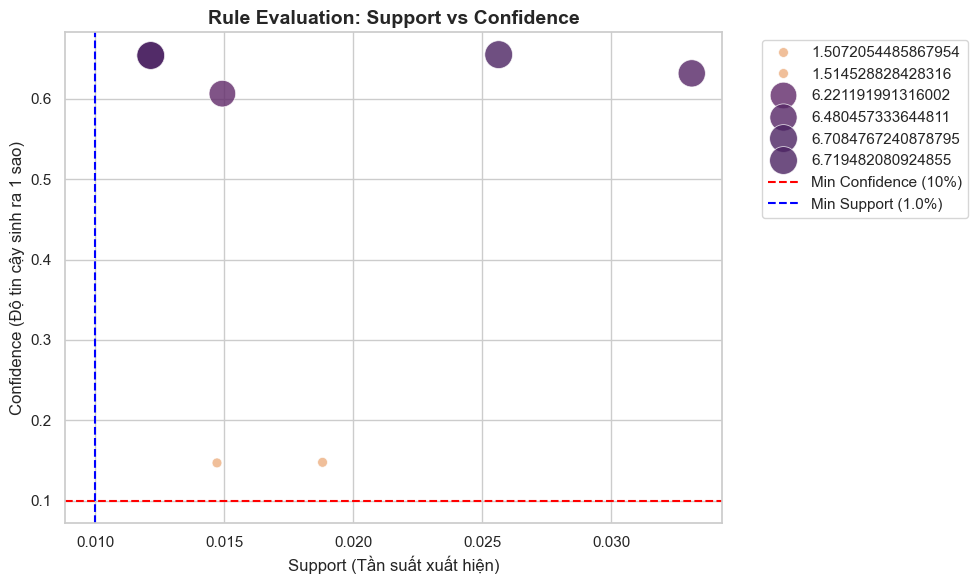

In [98]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Scatter plot: X-axis is Support, Y-axis is Confidence, Color and Size are Lift
scatter = sns.scatterplot(
    x="support", 
    y="confidence", 
    size="lift", 
    hue="lift",
    sizes=(50, 400), 
    palette="flare", 
    data=risk_rules, 
    alpha=0.8
)

# Thresholds
plt.axhline(y=0.1, color='red', linestyle='--', label='Min Confidence (10%)')
plt.axvline(x=0.01, color='blue', linestyle='--', label='Min Support (1.0%)')

plt.title('Rule Evaluation: Support vs Confidence', fontsize=14, fontweight='bold')
plt.xlabel('Support (Tần suất xuất hiện)', fontsize=12)
plt.ylabel('Confidence (Độ tin cậy sinh ra 1 sao)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()